In [1]:
import pandas as pd

results = pd.read_csv("results.csv")

results.columns.tolist()

['date',
 'home_team',
 'away_team',
 'home_score',
 'away_score',
 'tournament',
 'city',
 'country',
 'neutral']

In [2]:
rankings = pd.read_csv("fifa_ranking-2023-07-20.csv")

rankings.columns.tolist()

['rank',
 'country_full',
 'country_abrv',
 'total_points',
 'previous_points',
 'rank_change',
 'confederation',
 'rank_date']

In [3]:
elo = pd.read_csv("eloratings.csv")

elo.columns.tolist()

['date', 'team', 'rating', 'change']

In [5]:
former = pd.read_csv("former_names.csv")

former.columns.tolist()

['current', 'former', 'start_date', 'end_date']

In [6]:
!pip install xgboost -q

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [8]:
results = pd.read_csv("results.csv")

rankings = pd.read_csv(
    "fifa_ranking-2023-07-20.csv"
)

elo = pd.read_csv("eloratings.csv")

former = pd.read_csv("former_names.csv")

In [9]:
print("Results:", results.shape)

print("Rankings:", rankings.shape)

print("Elo:", elo.shape)

print("Former:", former.shape)

Results: (49477, 9)
Rankings: (64757, 8)
Elo: (6678, 4)
Former: (36, 4)


In [10]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [11]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  object 
 1   home_team   49477 non-null  object 
 2   away_team   49477 non-null  object 
 3   home_score  49405 non-null  float64
 4   away_score  49405 non-null  float64
 5   tournament  49477 non-null  object 
 6   city        49477 non-null  object 
 7   country     49477 non-null  object 
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [12]:
results["date"] = pd.to_datetime(
    results["date"]
)

In [13]:
results.isnull().sum()

,0
date,0
home_team,0
away_team,0
home_score,72
away_score,72
tournament,0
city,0
country,0
neutral,0


In [14]:
results.drop_duplicates(
    inplace=True
)

In [15]:
results["home_win"] = np.where(

    results["home_score"]

    >

    results["away_score"],

    1,

    0

)

In [16]:
results["home_win"].value_counts()

,count
home_win,
0,25265
1,24212


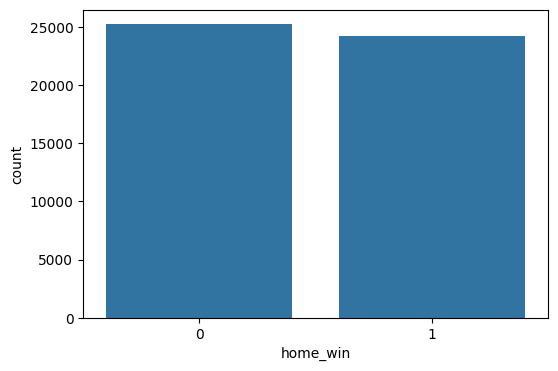

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="home_win",
    data=results
)

plt.show()

In [18]:
results["home_team"]\
.value_counts()\
.head(10)

,count
home_team,
Brazil,616
Argentina,608
Mexico,605
Germany,556
England,552
South Korea,552
France,540
Sweden,535
United States,502


In [19]:
results["away_team"]\
.value_counts()\
.head(10)

,count
away_team,
Uruguay,585
Sweden,569
England,541
Hungary,507
Paraguay,497
Germany,478
Argentina,464
Poland,463
Zambia,461


In [20]:
results["home_score"].describe()

,home_score
count,49405.000000
mean,1.757251
std,1.774294
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,31.000000


In [21]:
results["away_score"].describe()

,away_score
count,49405.000000
mean,1.181925
std,1.402073
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,21.000000


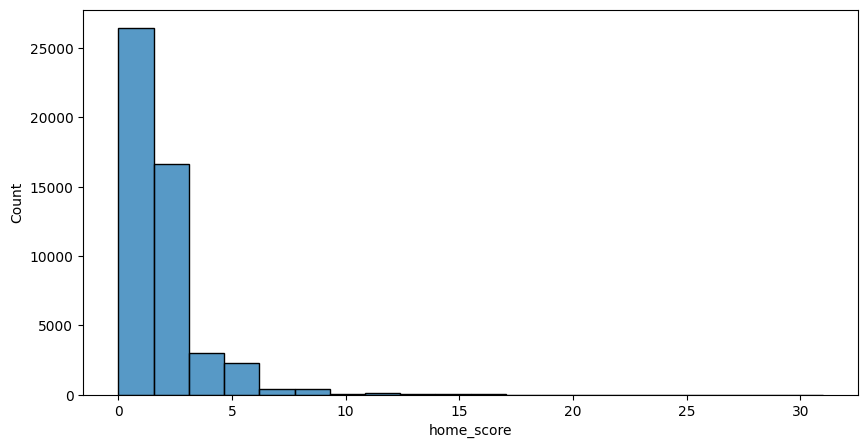

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    results["home_score"],
    bins=20
)

plt.show()

In [23]:
rankings["rank_date"] = pd.to_datetime(
    rankings["rank_date"]
)

In [24]:
latest_rank = rankings.sort_values(
    "rank_date"
).groupby(
    "country_full"
).tail(1)

In [25]:
latest_rank = latest_rank[
    [
        "country_full",
        "rank",
        "total_points"
    ]
]

In [26]:
latest_rank.columns = [

    "team",

    "fifa_rank",

    "fifa_points"

]

In [28]:
elo["date"] = pd.to_datetime(
    elo["date"],
    format="mixed",
    errors="coerce"
)

In [29]:
elo["date"].head()

,date
0,1872-11-30
1,1872-11-30
2,1873-03-08
3,1873-03-08
4,1874-03-07


In [30]:
elo["date"].isnull().sum()

np.int64(0)

In [31]:
latest_elo = elo.sort_values(
    "date"
).groupby(
    "team"
).tail(1)

In [32]:
latest_elo = latest_elo[
    [
        "team",
        "rating"
    ]
]

In [33]:
results = results.merge(

    latest_rank,

    left_on="home_team",

    right_on="team",

    how="left"

)

results.rename(

    columns={

        "fifa_rank":"home_rank",

        "fifa_points":"home_points"

    },

    inplace=True

)

In [34]:
results = results.merge(

    latest_rank,

    left_on="away_team",

    right_on="team",

    how="left"

)

results.rename(

    columns={

        "fifa_rank":"away_rank",

        "fifa_points":"away_points"

    },

    inplace=True

)

In [35]:
results = results.merge(

    latest_elo,

    left_on="home_team",

    right_on="team",

    how="left"

)

results.rename(

    columns={

        "rating":"home_elo"

    },

    inplace=True

)

In [38]:
results = results.drop(
    columns=["team_x", "team_y"],
    errors="ignore"
)

In [39]:
results = results.merge(

    latest_elo,

    left_on="away_team",

    right_on="team",

    how="left"

)

results.rename(

    columns={

        "rating":"away_elo"

    },

    inplace=True

)

In [40]:
results["rank_difference"] = (

    results["away_rank"]

    -

    results["home_rank"]

)

In [41]:
results["elo_difference"] = (

    results["home_elo"]

    -

    results["away_elo"]

)

In [42]:
results["home_advantage"] = np.where(

    results["neutral"] == False,

    1,

    0

)

In [43]:
features = [

    "home_rank",

    "away_rank",

    "home_points",

    "away_points",

    "home_elo",

    "away_elo",

    "rank_difference",

    "elo_difference",

    "home_advantage"

]

In [44]:
model_df = results[
    features + ["home_win"]
].dropna()

In [45]:
X = model_df[features]

y = model_df["home_win"]

In [46]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [47]:
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=5000)

In [48]:
lr_pred = lr.predict(
    X_test
)

In [49]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        lr_pred
    )
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Accuracy: 0.659641895103787
              precision    recall  f1-score   support

           0       0.67      0.68      0.68      3283
           1       0.65      0.63      0.64      3028

    accuracy                           0.66      6311
   macro avg       0.66      0.66      0.66      6311
weighted avg       0.66      0.66      0.66      6311



In [50]:
rf = RandomForestClassifier(

    n_estimators=300,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [51]:
rf_pred = rf.predict(
    X_test
)

In [52]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Accuracy: 0.6773886864205356
              precision    recall  f1-score   support

           0       0.69      0.70      0.69      3283
           1       0.67      0.65      0.66      3028

    accuracy                           0.68      6311
   macro avg       0.68      0.68      0.68      6311
weighted avg       0.68      0.68      0.68      6311



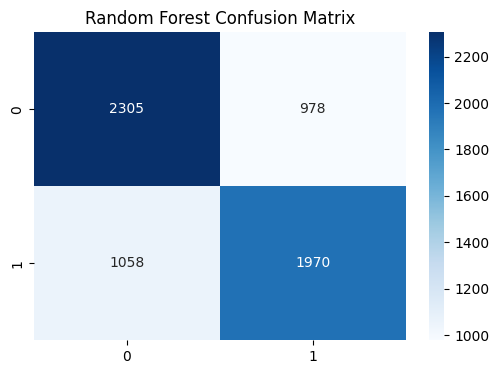

In [53]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [54]:
xgb = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    random_state=42,

    eval_metric="logloss"

)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [55]:
xgb_pred = xgb.predict(
    X_test
)

In [56]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        xgb_pred
    )
)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

Accuracy: 0.6824591982253209
              precision    recall  f1-score   support

           0       0.69      0.70      0.70      3283
           1       0.67      0.66      0.67      3028

    accuracy                           0.68      6311
   macro avg       0.68      0.68      0.68      6311
weighted avg       0.68      0.68      0.68      6311



In [57]:
scores = cross_val_score(

    rf,

    X,

    y,

    cv=5,

    scoring="accuracy"

)

print(scores)

print(
    "Average Accuracy:",
    scores.mean()
)

[0.5942006  0.63708399 0.66988906 0.68652932 0.70982567]
Average Accuracy: 0.6595057305672862


In [58]:
results_df = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        ),

        accuracy_score(
            y_test,
            xgb_pred
        )

    ]
})

results_df

,Model,Accuracy
0,Logistic Regression,0.659642
1,Random Forest,0.677389
2,XGBoost,0.682459


In [59]:
results_df.sort_values(

    "Accuracy",

    ascending=False

)

,Model,Accuracy
2,XGBoost,0.682459
1,Random Forest,0.677389
0,Logistic Regression,0.659642


In [60]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":
    rf.feature_importances_

})

In [61]:
importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance

,Feature,Importance
7,elo_difference,0.276977
6,rank_difference,0.271123
1,away_rank,0.079975
0,home_rank,0.075777
5,away_elo,0.072121
2,home_points,0.065801
3,away_points,0.063169
4,home_elo,0.062203
8,home_advantage,0.032855


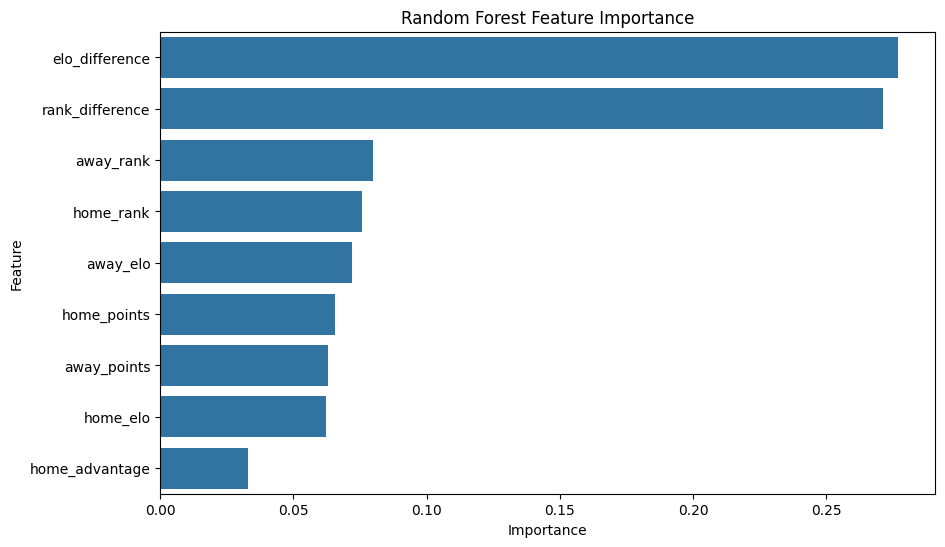

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [67]:
joblib.dump(
    rf,
    "football_match_predictor.pkl",
    compress=9
)

['football_match_predictor.pkl']

In [68]:
model = joblib.load(
    "football_match_predictor.pkl"
)

In [69]:
sample = X_test.iloc[[0]]

prediction = model.predict(
    sample
)

prediction

array([0])

In [70]:
model.predict_proba(
    sample
)

array([[0.79298079, 0.20701921]])